<a href="https://colab.research.google.com/github/Thcastro2004/ECSE551-A2-ML-for-engineers/blob/main/Barnett_Cottereau_Zhang_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 - CNN

In [13]:
#import statements
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from PIL import Image
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi
from tqdm import tqdm
import importlib
import datasets
importlib.reload(datasets)
from datasets import TrainingDataset, TestingDataset, Test551, Dataset551, Task2TrainingDataset, Task2TestDataset

# Create directory for generated files
os.makedirs('@generated-data', exist_ok=True)

Download the Kaggle dataset

In [16]:
# Download Kaggle competition data if not already present
if not os.path.exists('./data/train') or not os.path.exists('./data/test'):
    api = KaggleApi()
    api.authenticate()
    os.makedirs('./data', exist_ok=True)
    
    competition_name = 'ecse-551-assignment-2-task-2'
    api.competition_download_files(competition_name, path='./data')
    
    zip_path = f'./data/{competition_name}.zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('./data/')
        os.remove(zip_path)

Importing and pre-processing data using a custom Dataset for the training dataset

In [17]:
# Class definition moved to datasets.py - imported in Cell 2
# class TrainingDataset(Dataset): #10000 samples with labels, performs random data augmentation
#   def __init__(self):
#     super().__init__()
#     self.df = pd.read_csv('./data/kaggle_challenge/train_labels.csv')
#     self.trainpath = './data/kaggle_challenge/train/'
#     self.transform = transforms.Compose([
#         transforms.RandomApply(nn.ModuleList([transforms.RandomResizedCrop(size=(32,32), scale=(0.8,1))]),p=0.1),
#         transforms.RandomApply(nn.ModuleList([transforms.RandomRotation((1,5))]),p=0.1),
#         transforms.RandomHorizontalFlip(p=0.1),
#         transforms.RandomApply(nn.ModuleList([transforms.ColorJitter((0.7,1),(0.7,1),(0.7,1),(-0.1,0.1))]),p=0.1),
#         transforms.ToTensor(), #converts a PIL image to a Pytorch Tensor
#         transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
#         ])
#     self.labels_dict = {
#     "truck": 0,
#     "deer": 1,
#     "bird": 2,
#     "frog": 3,
#     "ship": 4,
#     "horse": 5,
#     "cat": 6,
#     "dog": 7,
#     "automobile": 8,
#     "airplane": 9
# }
#     return
#
#   def __getitem__(self, idx):
#     img = Image.open(self.trainpath+self.df.at[idx, "id"])
#     img = img.convert("RGB")
#     img = self.transform(img)
#     label = self.labels_dict.get(self.df.at[idx, "label"])
#     return img, label
#
#   def __len__(self):
#     return len(self.df)

In [18]:
# Class definition moved to datasets.py - imported in Cell 2
# class TestingDataset(Dataset): #10000 samples with labels, no transformations
#   def __init__(self):
#     super().__init__()
#     self.df = pd.read_csv('./data/kaggle_challenge/train_labels.csv')
#     self.trainpath = './data/kaggle_challenge/train/'
#     self.transform = transforms.Compose([
#         transforms.ToTensor(), #converts a PIL image to a Pytorch Tensor
#         transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
#         ])
#     self.labels_dict = {
#     "truck": 0,
#     "deer": 1,
#     "bird": 2,
#     "frog": 3,
#     "ship": 4,
#     "horse": 5,
#     "cat": 6,
#     "dog": 7,
#     "automobile": 8,
#     "airplane": 9
#   }
#     return
#
#   def __getitem__(self, idx):
#     img = Image.open(self.trainpath+self.df.at[idx, "id"])
#     img = img.convert("RGB")
#     img = self.transform(img)
#     label = self.labels_dict.get(self.df.at[idx, "label"])
#     return img, label
#
#   def __len__(self):
#     return len(self.df)

CNN Class Definition

In [19]:
class CNN(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
    self.conv5 = nn.Conv2d(128, 256, 4, padding=1)
    self.conv6 = nn.Conv2d(256, 512, 4, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.lin1 = nn.Linear(8192, 4096)
    self.lin2 = nn.Linear(4096, 512)
    self.lin3 = nn.Linear(512, 128)
    self.lin4 = nn.Linear(128, 10)
    self.batchnorm1 = nn.BatchNorm2d(16)
    self.batchnorm2 = nn.BatchNorm2d(32)
    self.batchnorm3 = nn.BatchNorm2d(64)
    self.batchnorm4 = nn.BatchNorm2d(128)
    self.batchnorm5 = nn.BatchNorm2d(256)
    self.batchnorm6 = nn.BatchNorm2d(512)
    self.dropout = nn.Dropout(0.3)
    return

  def forward(self, x):
    x = nn.functional.relu(self.batchnorm1(self.conv1(x)))
    x = nn.functional.relu(self.batchnorm2(self.conv2(x)))
    x = self.pool(x)
    x = nn.functional.relu(self.batchnorm3(self.conv3(x)))
    x = nn.functional.relu(self.batchnorm4(self.conv4(x)))
    x = self.pool(x)
    # x = nn.functional.relu(self.batchnorm5(self.conv5(x)))
    # x = nn.functional.relu(self.batchnorm6(self.conv6(x)))
    # x = self.pool(x)
    x = torch.flatten(x, 1)
    x = nn.functional.relu(self.lin1(x))
    x = self.dropout(x)
    x = nn.functional.relu(self.lin2(x))
    x = self.dropout(x)
    x = nn.functional.relu(self.lin3(x))
    x = self.dropout(x)
    x = self.lin4(x)
    return x

CNN Training

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
CUDA version: 12.8
GPU count: 1

Fold 1


Epoch 1/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:12<00:00,  6.84it/s, loss=1.8164]


Epoch 1/5 - Average Loss: 2.0310


Epoch 2/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 114.27it/s, loss=1.7920]


Epoch 2/5 - Average Loss: 1.6970


...

Epoch 3/5 - Average Loss: 1.5500


Epoch 4/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 119.08it/s, loss=1.3428]


Epoch 4/5 - Average Loss: 1.4462


Epoch 5/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 117.31it/s, loss=1.2938]


Epoch 5/5 - Average Loss: 1.3595


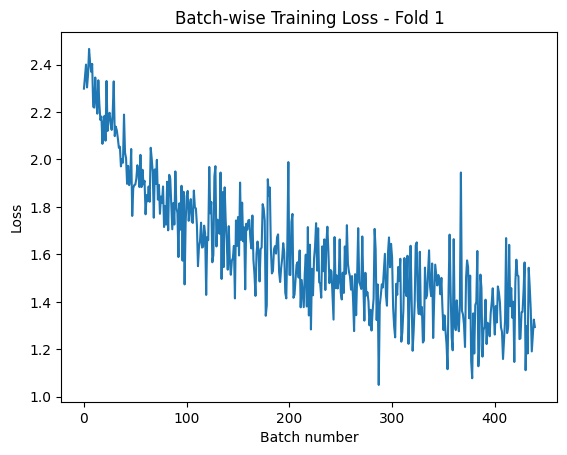

Evaluating fold 1...


Validation: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 22/22 [00:09<00:00,  2.43it/s]


Fold 1 Accuracy: 0.4621
Current Results: [0.46214285714285713]

Fold 2


Epoch 1/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:09<00:00,  9.68it/s, loss=1.6975]


Epoch 1/5 - Average Loss: 2.0026


...

Epoch 3/5 - Average Loss: 1.5294


Epoch 4/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 122.69it/s, loss=1.3995]


Epoch 4/5 - Average Loss: 1.3914


Epoch 5/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 122.62it/s, loss=1.6482]


Epoch 5/5 - Average Loss: 1.2851


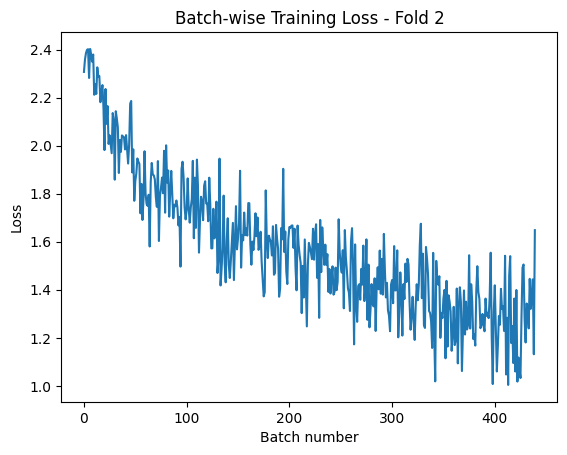

Evaluating fold 2...


Validation: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 22/22 [00:08<00:00,  2.73it/s]


Fold 2 Accuracy: 0.5436
Current Results: [0.46214285714285713, 0.5435714285714286]

Fold 3


Epoch 1/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:08<00:00,  9.82it/s, loss=1.9877]


Epoch 1/5 - Average Loss: 1.9948


...

Epoch 3/5 - Average Loss: 1.5035


Epoch 4/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 116.79it/s, loss=0.9510]


Epoch 4/5 - Average Loss: 1.3937


Epoch 5/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 116.39it/s, loss=1.7286]


Epoch 5/5 - Average Loss: 1.3011


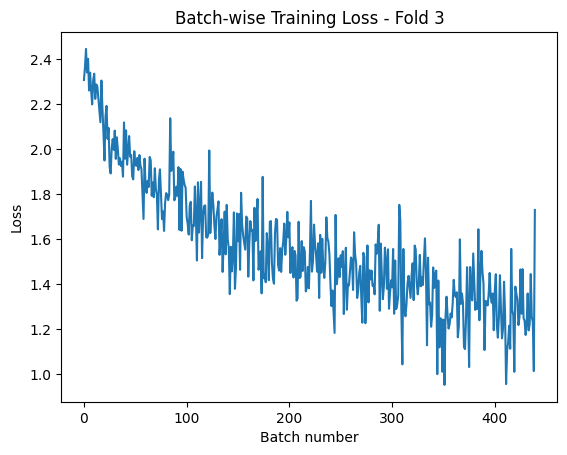

Evaluating fold 3...


Validation: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 22/22 [00:07<00:00,  2.75it/s]


Fold 3 Accuracy: 0.5414
Current Results: [0.46214285714285713, 0.5435714285714286, 0.5414285714285715]

Fold 4


Epoch 1/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:09<00:00,  9.71it/s, loss=1.6939]


Epoch 1/5 - Average Loss: 2.0754


...

Epoch 3/5 - Average Loss: 1.5646


Epoch 4/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 119.64it/s, loss=1.5055]


Epoch 4/5 - Average Loss: 1.4419


Epoch 5/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 120.65it/s, loss=1.1378]


Epoch 5/5 - Average Loss: 1.3300


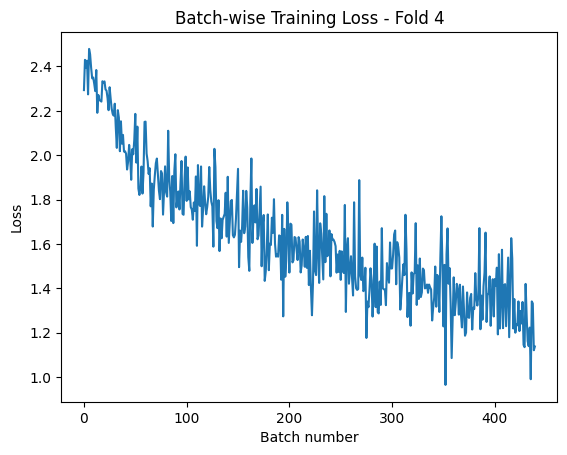

Evaluating fold 4...


Validation: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 22/22 [00:08<00:00,  2.72it/s]


Fold 4 Accuracy: 0.5279
Current Results: [0.46214285714285713, 0.5435714285714286, 0.5414285714285715, 0.5278571428571428]

Fold 5


Epoch 1/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:09<00:00,  9.55it/s, loss=1.7072]


Epoch 1/5 - Average Loss: 2.0099


...

Epoch 3/5 - Average Loss: 1.4954


Epoch 4/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 116.23it/s, loss=1.4232]


Epoch 4/5 - Average Loss: 1.3757


Epoch 5/5: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 88/88 [00:00<00:00, 114.26it/s, loss=1.2577]


Epoch 5/5 - Average Loss: 1.2559


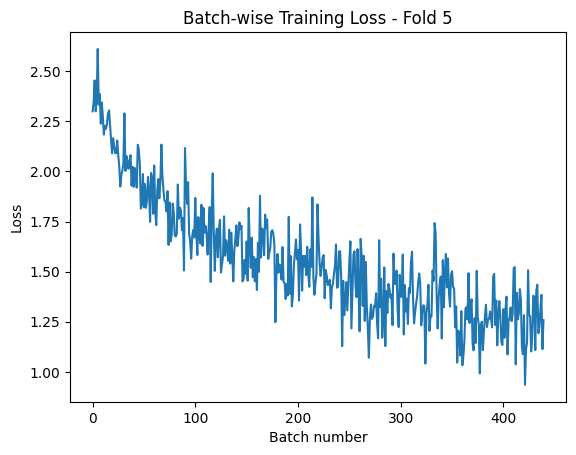

Evaluating fold 5...


Validation: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 22/22 [00:08<00:00,  2.74it/s]

Fold 5 Accuracy: 0.5457
Current Results: [0.46214285714285713, 0.5435714285714286, 0.5414285714285715, 0.5278571428571428, 0.5457142857142857]

Cross-Validation Complete!
All Results: [0.46214285714285713, 0.5435714285714286, 0.5414285714285715, 0.5278571428571428, 0.5457142857142857]
Mean Accuracy: 0.5241


In [ ]:
#split training data
training_dataset = TrainingDataset() #initiate Dataset
testing_dataset = TestingDataset()

indices = list(range(len(training_dataset)))
train_indices, test_indices = train_test_split(indices, test_size=0.3, random_state=42)
train_dataset = Subset(training_dataset, train_indices)
validation_dataset = Subset(testing_dataset, train_indices)
final_test_dataset = Subset(testing_dataset, test_indices) #for final model performance analysis

# GPU setup with better detection
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Using device: {device} (Apple Silicon GPU)")
else:
    device = torch.device('cpu')
    print(f"Using device: {device}")
    print("No GPU detected. Checking PyTorch installation...")
    print(f"PyTorch version: {torch.__version__}")
    if 'cpu' in torch.__version__.lower():
        print("WARNING: CPU-only PyTorch detected. Install CUDA version for GPU support:")
        print("  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")

results = []
weights = []
kf = KFold(shuffle=True, random_state=42)

for i, (train_idx, test_idx) in enumerate(kf.split(train_indices)):
  print(f"\n{'='*50}")
  print(f"Fold {i+1}")
  print(f"{'='*50}")
  
  cnn = CNN()
  cnn = cnn.to(device)
  cnn.train()
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(cnn.parameters(), 0.0003, weight_decay=0.0001)

  kf_train_dataset = Subset(train_dataset, train_idx)
  kf_train_dataloader = DataLoader(kf_train_dataset, batch_size=64, shuffle=True, num_workers=2, persistent_workers=True)
  kf_test_dataset = Subset(validation_dataset, test_idx)
  kf_test_dataloader = DataLoader(kf_test_dataset, batch_size=64, shuffle=False, num_workers=2 persistent_workers=True)

  training_loss = []
  num_epochs = 5
  
  for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    # Progress bar for batches
    pbar = tqdm(kf_train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=100)
    for input, label in pbar:
      input, label = input.to(device), label.to(device)
      output = cnn(input)
      loss = loss_function(output, label)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      
      loss_item = loss.item()
      training_loss.append(loss_item)
      epoch_loss += loss_item
      num_batches += 1
      
      # Update progress bar with current loss
      pbar.set_postfix({'loss': f'{loss_item:.4f}'})
      pbar.update()
    
    avg_epoch_loss = epoch_loss / num_batches
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {avg_epoch_loss:.4f}")

  plt.plot(training_loss)
  plt.xlabel("Batch number")
  plt.ylabel("Loss")
  plt.title(f"Batch-wise Training Loss - Fold {i+1}")
  plt.show()
  fold_filename = f"@generated-data/cnn_fold_{i+1}.pth"
  torch.save(cnn.state_dict(), fold_filename)

  # Validation
  print(f"Evaluating fold {i+1}...")
  cnn.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for input, label in tqdm(kf_test_dataloader, desc="Validation", ncols=100):
      input, label = input.to(device), label.to(device)
      output = cnn(input)
      prediction = output.argmax(dim=1)
      correct += (prediction == label).sum().item()
      total += label.size(0)
  
  fold_accuracy = correct / total
  results.append(fold_accuracy)
  print(f"Fold {i+1} Accuracy: {fold_accuracy:.4f}")
  print(f"Current Results: {results}")

print(f"\n{'='*50}")
print(f"Cross-Validation Complete!")
print(f"All Results: {results}")
print(f"Mean Accuracy: {np.mean(results):.4f}")
print(f"{'='*50}")

In [21]:
# from google.colab import drive
# drive.mount('/content/drive')
# Commented out - not needed for local execution

CNN Performance Evaluation

Creating a Dataset for the 2000 unlabelled images for Kaggle

In [22]:
# Class definition moved to datasets.py - imported in Cell 2
# class Test551(Dataset): #2000
#
#   def __init__(self):
#     super().__init__()
#     self.df = pd.read_csv('./data/kaggle_challenge/sample_submission.csv')
#     self.trainpath = './data/kaggle_challenge/test/'
#     self.transform = transforms.ToTensor() #converts a PIL image to a Pytorch Tensor
#     self.labels_dict = {
#     "truck": 0,
#     "deer": 1,
#     "bird": 2,
#     "frog": 3,
#     "ship": 4,
#     "horse": 5,
#     "cat": 6,
#     "dog": 7,
#     "automobile": 8,
#     "airplane": 9
#     }
#     return
#
#   def __getitem__(self, idx):
#     img = Image.open(self.trainpath+self.df.at[idx, "id"])
#     img = img.convert("RGB")
#     img = self.transform(img)
#     label = 0 #no labels assigned since this is the test set
#     return img, label
#
#   def __len__(self):
#     return len(self.df)

CNN Prediction for Kaggle

In [ ]:

kaggle_dataset = Test551()
kaggle_dataloader = DataLoader(kaggle_dataset, batch_size=64, shuffle=True, num_workers=2, persistent_workers=True)


for input, label in kaggle_dataloader:
  #output =
  pass


In [24]:
conv1 = nn.Conv2d(3, 16, 3, padding=1)
conv2 = nn.Conv2d(16, 32, 3, padding=1)
pool = nn.MaxPool2d(2, 2)
conv3 = nn.Conv2d(32, 64, 4, padding=1)
conv4 = nn.Conv2d(64, 128, 4, padding=1)
conv5 = nn.Conv2d(128, 256, 3, padding=1)
conv6 = nn.Conv2d(256, 512, 3, padding=1)
lin1 = nn.Linear(8192, 512)
lin2 = nn.Linear(512, 128)
lin3 = nn.Linear(128, 10)
batchnorm1 = nn.BatchNorm2d(16)
batchnorm2 = nn.BatchNorm2d(32)
batchnorm3 = nn.BatchNorm2d(64)
batchnorm4 = nn.BatchNorm2d(128)
batchnorm5 = nn.BatchNorm2d(256)
batchnorm6 = nn.BatchNorm2d(512)

x = torch.randn(1, 3, 32, 32)
x = nn.functional.relu(batchnorm1(conv1(x)))
x = nn.functional.relu(batchnorm2(conv2(x)))
x = pool(x)
x = nn.functional.relu(batchnorm3(conv3(x)))
x = nn.functional.relu(batchnorm4(conv4(x)))
x = pool(x)
# x = nn.functional.relu(conv5(x))
# x = nn.functional.relu(conv6(x))
# x = pool(x)
x = torch.flatten(x, 1)

flattened_size = x.shape[1]
print(flattened_size)
# x = nn.functional.relu(lin1(x))
# x = nn.functional.relu(lin2(x))
# x = lin3(x)


6272


# Task 1 - Vision Transformer

In [29]:
dataset = Dataset551()


# Task 2 - Free for All

In [30]:
# Import additional libraries for Task 2
import torchvision.models as models
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
import torch.nn.functional as F


## Task 2 Additional Imports

Imports additional libraries needed for Task 2:
- **torchvision.models**: Pre-trained models (ResNet, EfficientNet, ViT, etc.)
- **Learning rate schedulers**: StepLR and CosineAnnealingLR for better training
- **torch.nn.functional**: Additional neural network functions


## Task 2 Strategy Options:

1. **Transfer Learning with Pre-trained Models**: Use ResNet, EfficientNet, or Vision Transformer pre-trained on ImageNet
2. **Ensemble Methods**: Combine predictions from multiple models (your Task 1 models + pre-trained models)
3. **Advanced Data Augmentation**: Mixup, CutMix, AutoAugment
4. **Better Training**: Longer training, learning rate scheduling, better optimizers

### Recommended Approach:
Start with a pre-trained ResNet50 or EfficientNet, fine-tune on your dataset, then optionally ensemble with your Task 1 models.


## Pre-trained Model Creation Functions

Helper functions to create transfer learning models:
- **create_resnet_model()**: ResNet50 pre-trained on ImageNet, fine-tuned for 10 classes
- **create_efficientnet_model()**: EfficientNet-B3, a more efficient architecture
- **create_vit_model()**: Vision Transformer pre-trained on ImageNet

All models replace the final classification layer to match our 10-class problem.


## Task 2 Dataset Classes

Enhanced dataset classes for Task 2 with more aggressive data augmentation:

**Task2TrainingDataset**:
- Stronger augmentation (random crops, rotations, flips, color jitter, affine transforms)
- ImageNet normalization statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
- Higher augmentation probabilities for better generalization

**Task2TestDataset**:
- Minimal transformations for validation
- Same ImageNet normalization for consistency with pre-trained models


## Task 2 Training with Transfer Learning

Complete training pipeline for Task 2:
1. **Data preparation**: 80% train, 20% validation split
2. **Model setup**: ResNet50 with pre-trained ImageNet weights
3. **Training configuration**:
   - AdamW optimizer (lr=1e-4, weight_decay=1e-4)
   - Cosine annealing learning rate scheduler
   - 50 epochs
4. **Training loop**: Tracks training loss and validation accuracy
5. **Model checkpointing**: Saves the best model based on validation accuracy

This approach leverages transfer learning to achieve better performance with less training time.


In [32]:
# Example: Transfer Learning with ResNet50
# You can use ANY pre-trained model here (ResNet, EfficientNet, ViT, etc.)

def create_resnet_model(num_classes=10):
    # Load pre-trained ResNet50
    model = models.resnet50(weights='IMAGENET1K_V2')
    
    # Replace the final fully connected layer for 10 classes
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

# Alternative: EfficientNet
def create_efficientnet_model(num_classes=10):
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, num_classes)
    return model

# Alternative: Vision Transformer (pre-trained)
def create_vit_model(num_classes=10):
    model = models.vit_b_16(weights='IMAGENET1K_V1')
    num_features = model.heads.head.in_features
    model.heads.head = nn.Linear(num_features, num_classes)
    return model


## Task 2 Kaggle Submission Generation

Generates predictions for the Kaggle competition:
1. Loads the best trained model from Task 2
2. Runs inference on the test dataset
3. Converts class indices to label names
4. Creates a submission CSV file in the format required by Kaggle

The submission file can be directly uploaded to the competition leaderboard.


In [2]:
# Class definitions moved to datasets.py - imported in Cell 2
# Enhanced data augmentation for Task 2
# class Task2TrainingDataset(Dataset):
#     def __init__(self):
#         super().__init__()
#         self.df = pd.read_csv('./data/kaggle_challenge/train_labels.csv')
#         self.trainpath = './data/kaggle_challenge/train/'
#         # More aggressive augmentation for Task 2
#         self.transform = transforms.Compose([
#             transforms.RandomResizedCrop(size=(32, 32), scale=(0.7, 1.0)),
#             transforms.RandomRotation(degrees=15),
#             transforms.RandomHorizontalFlip(p=0.5),
#             transforms.RandomVerticalFlip(p=0.1),
#             transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
#             transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
#             transforms.ToTensor(),
#             transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
#         ])
#         self.labels_dict = {
#             "truck": 0, "deer": 1, "bird": 2, "frog": 3, "ship": 4,
#             "horse": 5, "cat": 6, "dog": 7, "automobile": 8, "airplane": 9
#         }
#     
#     def __getitem__(self, idx):
#         img = Image.open(self.trainpath + self.df.at[idx, "id"])
#         img = img.convert("RGB")
#         img = self.transform(img)
#         label = self.labels_dict.get(self.df.at[idx, "label"])
#         return img, label
#     
#     def __len__(self):
#         return len(self.df)
#
# class Task2TestDataset(Dataset):
#     def __init__(self):
#         super().__init__()
#         self.df = pd.read_csv('./data/kaggle_challenge/train_labels.csv')
#         self.trainpath = './data/kaggle_challenge/train/'
#         self.transform = transforms.Compose([
#             transforms.ToTensor(),
#             transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#         ])
#         self.labels_dict = {
#             "truck": 0, "deer": 1, "bird": 2, "frog": 3, "ship": 4,
#             "horse": 5, "cat": 6, "dog": 7, "automobile": 8, "airplane": 9
#         }
#     
#     def __getitem__(self, idx):
#         img = Image.open(self.trainpath + self.df.at[idx, "id"])
#         img = img.convert("RGB")
#         img = self.transform(img)
#         label = self.labels_dict.get(self.df.at[idx, "label"])
#         return img, label
#     
#     def __len__(self):
#         return len(self.df)


In [ ]:
# Task 2 Training with Cross-Validation
# Simple sequential training - one fold at a time

import os
import time
import importlib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

from torch import amp  # new AMP API

# Import datasets (reload in case you edited datasets.py)
import datasets
importlib.reload(datasets)
from datasets import Task2TrainingDataset, Task2TestDataset

# Model creation function (ResNet50 for 10 classes)
def create_resnet_model(num_classes=10):
    model = models.resnet50(weights='IMAGENET1K_V2')
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

print("="*60)
print("Task 2: Cross-Validation Training")
print("="*60)

# ------------------------------------------------------------------
# 1) Load data & create global train / held-out test split
# ------------------------------------------------------------------
print("\nLoading data...")
train_csv_data = pd.read_csv('./data/kaggle_challenge/train_labels.csv')
print(f"Loaded {len(train_csv_data)} samples")

all_indices = np.arange(len(train_csv_data))
train_indices, test_indices = train_test_split(
    all_indices, test_size=0.2, random_state=42
)
print(f"Training samples (for CV): {len(train_indices)}")
print(f"Test samples (held out): {len(test_indices)}")

# Save held-out test indices (for Task 3 / later use)
np.save('@generated-data/task2_test_indices.npy', test_indices)

# ------------------------------------------------------------------
# 2) Device & performance settings
# ------------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"\nUsing device: cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Let cuDNN pick the fastest algorithms for our fixed image size
    torch.backends.cudnn.benchmark = True
    use_amp = True
else:
    device = torch.device('cpu')
    print(f"\nUsing device: cpu")
    use_amp = False

# DataLoader workers: spawning many workers on Windows is often slower
num_workers = 4

pin_memory = (device.type == "cuda")
persistent_workers = num_workers > 0

print(f"\nDataLoader settings -> num_workers={num_workers}, "
      f"pin_memory={pin_memory}, persistent_workers={persistent_workers}")

# ------------------------------------------------------------------
# 3) Create datasets ONCE (reused across all folds)
# ------------------------------------------------------------------
task2_train_dataset = Task2TrainingDataset()
task2_test_dataset = Task2TestDataset()

# ------------------------------------------------------------------
# 4) Cross-validation configuration
# ------------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
batch_size = 128          # larger batch to better use the GPU
num_epochs = 50
val_frequency = 2         # validate every 2 epochs instead of every epoch

cv_results = []
fold_models = []

print(f"\n{'='*60}")
print("Starting 5-Fold Cross-Validation")
print(f"{'='*60}\n")

start_time = time.time()

# Pre-compute all fold splits
print("Pre-computing all fold splits...")
all_fold_splits = list(kf.split(train_indices))
print(f"Pre-computed {len(all_fold_splits)} fold splits\n")

# ------------------------------------------------------------------
# 5) Fold loop
# ------------------------------------------------------------------
for fold_idx, (cv_train_idx, cv_val_idx) in enumerate(all_fold_splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/5")
    print(f"{'='*60}")
    
    # Map fold indices (0..len(train_indices)-1) -> original indices (0..N-1)
    cv_train_indices = train_indices[cv_train_idx]
    cv_val_indices   = train_indices[cv_val_idx]
    
    # Subsets for this fold: training uses augmented dataset, validation uses test-style transforms
    fold_train_subset = Subset(task2_train_dataset, cv_train_indices.tolist())
    fold_val_subset   = Subset(task2_test_dataset, cv_val_indices.tolist())
    
    # DataLoaders
    fold_train_loader = DataLoader(
        fold_train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers
    )
    
    fold_val_loader = DataLoader(
        fold_val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers
    )
    
    # ------------------------------------------------------------------
    # Model, optimizer, scheduler, AMP scaler
    # ------------------------------------------------------------------
    model_task2 = create_resnet_model(num_classes=10).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model_task2.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    if use_amp and device.type == "cuda":
        # New AMP API
        scaler = amp.GradScaler('cuda')
    else:
        scaler = None
    
    fold_best_val_acc = 0.0
    fold_best_model_path = f"@generated-data/task2_fold_{fold_idx+1}.pth"
    
    # Single progress bar per fold (over epochs)
    epoch_pbar = tqdm(range(num_epochs), desc=f"Fold {fold_idx+1}/5 Training", leave=True)
    
    for epoch in epoch_pbar:
        model_task2.train()
        running_loss = 0.0
        num_batches = 0
        
        # -------------------- Training loop --------------------
        for inputs, labels in fold_train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            if scaler is not None:
                # New autocast API: must give device_type
                with amp.autocast(device_type='cuda'):
                    outputs = model_task2(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model_task2(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            running_loss += loss.item()
            num_batches += 1
        
        # Scheduler step once per epoch
        scheduler.step()
        
        # -------------------- Validation (every val_frequency epochs) --------------------
        if ((epoch + 1) % val_frequency == 0) or (epoch == num_epochs - 1):
            model_task2.eval()
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for inputs, labels in fold_val_loader:
                    inputs = inputs.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    outputs = model_task2(inputs)
                    _, predicted = torch.max(outputs, dim=1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            
            val_acc = val_correct / val_total
            if val_acc > fold_best_val_acc:
                fold_best_val_acc = val_acc
                # Save best model for this fold
                torch.save(model_task2.state_dict(), fold_best_model_path)
            
            avg_loss = running_loss / max(1, num_batches)
            epoch_pbar.set_postfix({
                "Epoch": f"{epoch+1}/{num_epochs}",
                "Loss": f"{avg_loss:.4f}",
                "Val Acc": f"{val_acc:.4f}",
                "Best": f"{fold_best_val_acc:.4f}"
            })
        else:
            # Still update loss even if we didn't validate this epoch
            avg_loss = running_loss / max(1, num_batches)
            epoch_pbar.set_postfix({
                "Epoch": f"{epoch+1}/{num_epochs}",
                "Loss": f"{avg_loss:.4f}",
                "Val Acc": "----",
                "Best": f"{fold_best_val_acc:.4f}"
            })
    
    epoch_pbar.close()
    
    print(f"\nFold {fold_idx+1} Complete | Best Val Acc: {fold_best_val_acc:.4f}")
    cv_results.append(fold_best_val_acc)
    fold_models.append(fold_best_model_path)

# ------------------------------------------------------------------
# 6) Cross-validation summary and saving best overall model
# ------------------------------------------------------------------
elapsed_time = time.time() - start_time

print(f"\n{'='*60}")
print("Cross-Validation Complete")
print(f"{'='*60}")

best_fold_idx = int(np.argmax(cv_results))
best_cv_acc = cv_results[best_fold_idx]

print("\nResults:")
for i, acc in enumerate(cv_results, 1):
    marker = " <-- BEST" if i == best_fold_idx + 1 else ""
    print(f"  Fold {i}: {acc:.4f}{marker}")

print(f"\nMean CV Accuracy: {np.mean(cv_results):.4f} ± {np.std(cv_results):.4f}")
print(f"Best Fold: {best_fold_idx+1} (accuracy: {best_cv_acc:.4f})")
print(f"Total Time: {elapsed_time/60:.2f} minutes")

# Save the best fold model as task2_best_model.pth
best_model_state = torch.load(fold_models[best_fold_idx], map_location="cpu")
torch.save(best_model_state, "@generated-data/task2_best_model.pth")
print("\nBest model saved to: @generated-data/task2_best_model.pth")
print("="*60)


Task 2: Cross-Validation Training

Loading data...
Loaded 10000 samples
Training samples (for CV): 8000
Test samples (held out): 2000

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti

DataLoader settings -> num_workers=0, pin_memory=True, persistent_workers=False

Starting 5-Fold Cross-Validation

Pre-computing all fold splits...
Pre-computed 5 fold splits


Fold 1/5


Fold 1/5 Training:  72%|███████▏  | 36/50 [02:48<01:07,  4.80s/it, Epoch=36/50, Loss=0.5108, Val Acc=0.7881, Best=0.7900]

In [2]:
# Task 2 Test Evaluation
# Evaluates the best model on the held-out test set

# Load datasets
task2_test_dataset = Task2TestDataset()

# Load test indices that were saved during training
test_indices = np.load('@generated-data/task2_test_indices.npy')

# GPU setup with error handling
device = torch.device('cpu')  # Default to CPU
if torch.cuda.is_available():
    try:
        # Test if CUDA actually works
        test_tensor = torch.zeros(1).cuda()
        del test_tensor
        torch.cuda.empty_cache()
        device = torch.device('cuda')
        print(f"Using device: {device}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
    except RuntimeError as e:
        print(f"CUDA detected but not working: {e}")
        print("Falling back to CPU")
        device = torch.device('cpu')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Using device: {device} (Apple Silicon GPU)")
else:
    print(f"Using device: {device}")

print(f"\n{'='*60}")
print("Evaluating Best Model on Test Set (held out during training)")
print(f"{'='*60}")

# Create test set loader
test_subset = Subset(task2_test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=4, persistent_workers=True)

# Load best model and evaluate on test set
model_task2 = create_resnet_model(num_classes=10)
model_task2.load_state_dict(torch.load('@generated-data/task2_best_model.pth', map_location='cpu'))
try:
    model_task2 = model_task2.to(device)
except RuntimeError as e:
    print(f"Error moving model to {device}: {e}")
    print("Falling back to CPU")
    device = torch.device('cpu')
    model_task2 = model_task2.to(device)
model_task2.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_task2(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = test_correct / test_total
print(f"Test Set Accuracy: {test_accuracy:.4f} ({test_correct}/{test_total})")
print(f"{'='*60}")


Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
CUDA version: 12.8

Evaluating Best Model on Test Set (held out during training)
Test Set Accuracy: 0.7940 (1588/2000)
